## DQN example

Warning :

I am trying to implement DQN example in Du(2020), but I think I didn't fully understand the paper

In [1]:
import torch
print(torch.cuda.is_available())
from rl import * 


True


In [ ]:
cfg = dict(
    S0=100.0, K=100.0, T=10.0/252.0, D =10, sigma=0.01, kappa=0.1, cost_multiplier=1.0, tick_size=0.1
)

rl.Config.action_space = [-10.0, -5.0, 0.0, 5.0, 10.0] # Need to be modified, but I think this is not the main problem

env = OptionReplicationEnv(
    **cfg
)
agent = dqn(state_dim = 4, hidden_dim =64)
optimizer = optim.Adam(agent.parameters(), lr= 0.001)
loss_log = []

for epoch in range(150):
    history = []
    print("epoch", epoch)

    # NUM_EPISODES = 3000
    NUM_EPISODES = 100

    # ==========================================
    # 1. Simulating the environment to gather Data
    # ==========================================
    for _ in range(NUM_EPISODES):
        state = env.reset()
        done = False
        while not done:
            action = agent.get_action(state, epsilon=0.1)
            next_state, reward, done = env.step(action)
            
            # IMPORTANT: Save 'next_state' and 'done' into history
            # we use float() for reward and done to ensure they are python floats, not tensors
            history.append((state, action, float(reward), next_state, float(done)))
            state = next_state
            
    # ==========================================
    # 2. Ensemble Sampling (Batch Training)
    # ==========================================
    # Sample 10% from the collected trajectories
    sample_size = int(len(history) * 0.1)

    if len(history) >= sample_size and sample_size > 0:
        # 1. Sample exactly `sample_size` transitions (breaks correlation)
        batch = random.sample(history, sample_size)
        
        # 2. Unpack the batch into separated lists using `zip(*batch)`
        states, actions, rewards, next_states, dones = zip(*batch)
        
        # 3. Stack lists into batched PyTorch Tensors
        states_t      = torch.stack(states)                            # Shape: [sample_size, 4]
        actions_t     = torch.tensor(actions, dtype=torch.long)        # Shape: [sample_size]
        rewards_t     = torch.tensor(rewards, dtype=torch.float32)     # Shape: [sample_size]
        next_states_t = torch.stack(next_states)                       # Shape: [sample_size, 4]
        dones_t       = torch.tensor(dones, dtype=torch.float32)       # Shape: [sample_size]
        
        # 4. Perform a SINGLE batched forward pass and loss calculation
        loss = agent.td_loss(states_t, actions_t, rewards_t, next_states_t, dones_t)
        
        # 5. One backprop step for the entire batch
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Collected total {len(history)} transitions.")
        print(f"Trained on {sample_size} samples (10%). Loss: {loss.item():.4f}")
        loss_log.append(loss.item())

epoch 0
Collected total 10100 transitions.
Trained on 1010 samples (10%). Loss: 2.8619
epoch 1
Collected total 10100 transitions.
Trained on 1010 samples (10%). Loss: 1.1830
epoch 2
Collected total 10100 transitions.
Trained on 1010 samples (10%). Loss: 4.6170
epoch 3
Collected total 10100 transitions.
Trained on 1010 samples (10%). Loss: 18.4354
epoch 4
Collected total 10100 transitions.
Trained on 1010 samples (10%). Loss: 3.3662
epoch 5
Collected total 10100 transitions.
Trained on 1010 samples (10%). Loss: 3.3802
epoch 6
Collected total 10100 transitions.
Trained on 1010 samples (10%). Loss: 2.8530
epoch 7
Collected total 10100 transitions.
Trained on 1010 samples (10%). Loss: 3.0737
epoch 8
Collected total 10100 transitions.
Trained on 1010 samples (10%). Loss: 3.0317
epoch 9
Collected total 10100 transitions.
Trained on 1010 samples (10%). Loss: 2.9271
epoch 10
Collected total 10100 transitions.
Trained on 1010 samples (10%). Loss: 1.7722
epoch 11
Collected total 10100 transition

KeyboardInterrupt: 

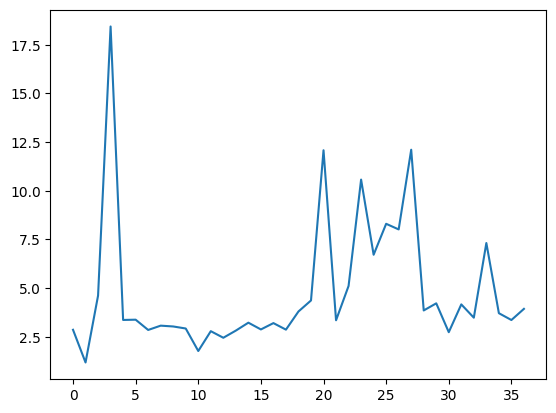

In [3]:
import matplotlib.pyplot as plt 
plt.plot(loss_log)

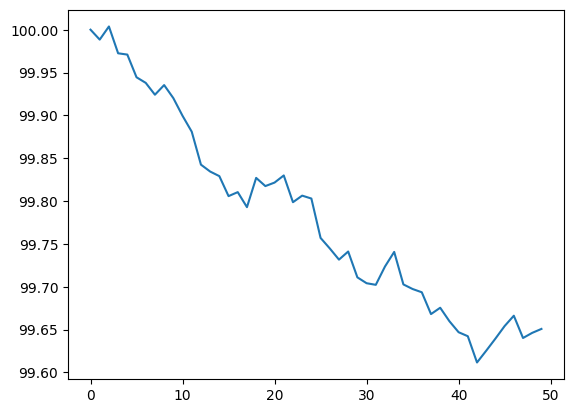

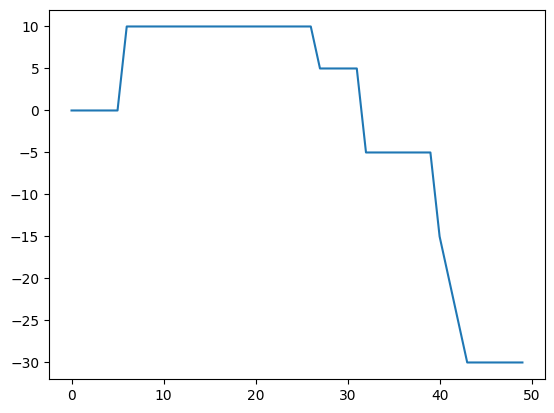

In [4]:
ss = []
ps = []
for state, _, _, _, _ in history:
    underlying, _, pos, _ = state.tolist()
    ss.append(underlying)
    ps.append(pos)

import matplotlib.pyplot as plt 
plt.plot(ss[:50])
plt.show()
plt.plot(ps[:50])
plt.show()